# **Obfuscation Detection in Financial Text Using FinBERT**

## Project Overview

This notebook implements a series of deep learning models to detect **obfuscation** in financial text (e.g., annual reports, earnings calls). Unlike traditional approaches that predict *tone* (positive/negative) and then regress on returns, this project directly predicts an **information-content construct: obfuscation**.

## **1. Setup and Library Imports**

This section imports all necessary libraries for data processing, model training, and evaluation.

- **Transformers**: Provides BERT tokenizer, model architecture, and training utilities.
- **Datasets**: Hugging Face's efficient dataset handling.
- **PyTorch**: Deep learning framework.
- **Scikit-learn**: Used for metrics, label encoding, and data splitting.
- **Textstat**: Computes readability scores (Fog index, SMOG, etc.) for linguistic feature extraction.

The `seed_everything()` function ensures reproducibility by fixing random seeds across Python, NumPy, PyTorch (CPU and GPU), and CuDNN. This is critical for obtaining consistent experimental results.

In [ ]:
# !pip install transformers==4.18.0
# !pip install numpy==1.19.5
# !pip install torch==1.7.1
# !pip install scikit-learn==0.20.3
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 48.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from transformers import BertTokenizer, Trainer, BertForSequenceClassification, TrainingArguments
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
from transformers import set_seed
from sklearn.preprocessing import LabelEncoder
import re
import torch.nn as nn
import textstat
from transformers import BertTokenizer, BertModel, Trainer, TrainingArguments, EarlyStoppingCallback
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
import random
import os
import numpy as np
import torch


In [ ]:

def seed_everything(seed=50):
    # 1. Basic Python randomness
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy randomness
    np.random.seed(seed)

    # 3. PyTorch CPU & GPU randomness
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU setups

    # 4. CuDNN Determinism (Crucial for Transformers)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Global seed set to: {seed}")

# --- CALL IT IMMEDIATELY ---
seed_everything(50)

Global seed set to: 50


## **2. Data Preprocessing and Balancing**

This cell defines the `preprocess_data()` function, which handles:

- **Text normalization**: Strips extra spaces, standardizes punctuation, removes unwanted characters.
- **Data cleaning**: Drops rows with missing values or invalid labels (`-1`).
- **Class balancing**: Uses **undersampling** to reduce the majority class size to match the minority class, preventing model bias.
- **Label encoding**: Converts class labels to binary integers (0/1) using `LabelEncoder`.

The function returns a balanced DataFrame and the fitted encoder for later use. This step ensures the dataset is clean, balanced, and ready for model input.

In [ ]:
import re


def preprocess_data(file_path, random_state=42, min_text_length=10):
    """
    Load and preprocess Excel data for binary classification.

    Parameters:
    -----------
    file_path : str
        Path to the Excel file
    random_state : int
        Random seed for reproducibility
    min_text_length : int
        Minimum text length to keep a sample

    Returns:
    --------
    pd.DataFrame
        Preprocessed and balanced DataFrame with encoded labels
    """

    def normalize_text(text):
        """Normalize text by cleaning and standardizing format."""
        text = re.sub(r'\s+', ' ', text).strip()
        text = re.sub(r'\s+([.,!?;:])', r'\1', text)
        text = re.sub(r'([.,!?;:])([^\s])', r'\1 \2', text)
        text = re.sub(r'[^a-zA-Z0-9\s\.\,\%\$\(\)\-\'\"]', '', text)
        text = re.sub(r'\.{2,}', '.', text)
        return text

    # Load data
    df = pd.read_excel(file_path)

    # Remove NaN values and invalid labels
    df = df.dropna()
    df = df[df['binary_label'] != -1].copy()

    # Normalize text
    df['text'] = df['text'].apply(normalize_text)

    # Filter by minimum text length
    df = df[df['text'].str.len() >= min_text_length]
    print(f"After cleaning and filtering: {len(df)}")

    # Check class balance
    label_counts = df['binary_label'].value_counts()
    majority_label = label_counts.idxmax()
    minority_label = label_counts.idxmin()
    minority_count = label_counts.min()

    print(f"Majority class: {majority_label} (count = {label_counts.max()})")
    print(f"Minority class: {minority_label} (count = {minority_count})")

    # Separate dataframes
    df_majority = df[df['binary_label'] == majority_label]
    df_minority = df[df['binary_label'] == minority_label]

    # Undersample majority class to match minority count
    df_majority_undersampled = df_majority.sample(n=minority_count, random_state=random_state)

    # Combine and shuffle
    df_balanced = pd.concat([df_majority_undersampled, df_minority], ignore_index=True)
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)

    print("\nBalanced class distribution after undersampling:")
    print(df_balanced['binary_label'].value_counts())

    # Encode labels
    label_encoder = LabelEncoder()
    df_balanced['binary_label'] = label_encoder.fit_transform(df_balanced['binary_label'])

    return df_balanced, label_encoder

# Usage example:
# df, encoder = preprocess_data('data.xlsx')
# df, encoder = preprocess_data('data.xlsx', random_state=123, min_text_length=20)

## **3. Hardware Verification**

Checks whether a GPU (e.g., Tesla T4 in Colab) is available. Training transformer models like FinBERT is significantly faster on GPU. This cell prints:
- GPU name (if available)
- PyTorch and CUDA versions

If no GPU is detected, the model will fall back to CPU (slower).

In [ ]:
import torch

# Check if CUDA (NVIDIA's parallel computing platform) is available
if torch.cuda.is_available():
    # Print the name of your assigned GPU, e.g., "Tesla T4"
    print(f"GPU is available! Using: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("GPU not available. Please check your runtime settings.")

GPU is available! Using: Tesla T4
PyTorch version: 2.10.0+cu128
CUDA version: 12.8


## **4. Baseline: Vanilla FinBERT Fine-tuning**

This section fine-tunes the pre-trained **FinBERT** model (from `yiyanghkust/finbert-pretrain`) on the binary obfuscation classification task.

**Steps**:
1. Load and preprocess data (using the function above).
2. Split into train (80%), validation (10%), and test (10%).
3. Load the **FinBERT model** and **tokenizer**.
4. Tokenize text with `max_length=128`, padding, and truncation.
5. Define `compute_metrics()` to calculate accuracy, F1, precision, and recall.
6. Configure `TrainingArguments` with:
   - Learning rate: 2e-6
   - Batch size: 8
   - Epochs: 5
   - Weight decay: 0.05
   - Early stopping with patience = 2
7. Train and evaluate on the test set.

This serves as a **baseline** model against which enhanced versions will be compared.

In [ ]:
# Split dataset into training, validation, and testing sets
df, encoder = preprocess_data('data.xlsx')

df_train, df_test = train_test_split(df, test_size=0.1, random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=42)

# Load the FinBERT pretrained model
model = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-pretrain', num_labels=2) # Assuming you have 3 labels: positive, negative, neutral
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-pretrain')

# Prepare datasets for fine-tuning
dataset_train = Dataset.from_pandas(df_train)
dataset_val = Dataset.from_pandas(df_val)
dataset_test = Dataset.from_pandas(df_test)
# Tokenize datasets
def tokenize_data(example):
    return tokenizer(example['text'], truncation=True, padding='max_length', max_length=128)

dataset_train = dataset_train.map(tokenize_data, batched=True)
dataset_val = dataset_val.map(tokenize_data, batched=True)
dataset_test = dataset_test.map(tokenize_data, batched=True)

# Set dataset format
dataset_train = dataset_train.rename_column("binary_label", "labels")
dataset_val = dataset_val.rename_column("binary_label", "labels")
dataset_test = dataset_test.rename_column("binary_label", "labels")
dataset_train.set_format(type='torch', columns=['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
dataset_val.set_format(type='torch', columns=['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
dataset_test.set_format(type='torch', columns=['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

# Define training options and metrics
# def compute_metrics(eval_pred):
#     predictions, labels = eval_pred
#     predictions = np.argmax(predictions, axis=1)
#     return {'accuracy' : accuracy_score(predictions, labels)}

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

args = TrainingArguments(
    output_dir='temp/',
    load_best_model_at_end=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    seed=50,           # The internal seed for the trainer
    data_seed=50,
    label_names=['labels'],
    learning_rate=2e-6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.05,
    max_grad_norm=0.5,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
)

from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    train_dataset=dataset_train,
    eval_dataset=dataset_val,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()
print(trainer.evaluate(dataset_test))

After cleaning and filtering: 3730
Majority class: 1.0 (count = 2605)
Minority class: 0.0 (count = 1125)

Balanced class distribution after undersampling:
binary_label
1.0    1125
0.0    1125
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

Map:   0%|          | 0/1822 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.42677071690559387, 'eval_accuracy': 0.7955555555555556, 'eval_f1': 0.8, 'eval_precision': 0.8, 'eval_recall': 0.8, 'eval_runtime': 1.7349, 'eval_samples_per_second': 129.693, 'eval_steps_per_second': 16.716, 'epoch': 5.0}


In [ ]:
import gc
import torch

# Delete the existing trainer and model objects
if 'trainer' in locals():
    del trainer
if 'model' in locals():
    del model

# Trigger Python garbage collection
gc.collect()

# Clear the PyTorch cache
torch.cuda.empty_cache()

## **5. Hybrid Model: FinBERT with Simple Linguistic Features**

This cell augments FinBERT with **handcrafted linguistic features** to improve obfuscation detection.

### Feature Extraction (`extract_simple_features`)
Computes 8 features per document:
- Gunning Fog Index (readability)
- Average sentence length
- Average word length
- Polysyllabic word ratio
- Exclamation mark ratio
- Question mark ratio
- Word count
- Sentence count

### Hybrid Architecture (`FinBertHybrid`)
- BERT processes text → generates 768‑dim embedding
- Concatenates BERT output with scaled linguistic features
- Passes combined vector through a linear classifier

### Training
- Features are standardized using `StandardScaler`
- Same hyperparameters as vanilla FinBERT
- Uses **F1 score** as the metric for best model (more robust for imbalanced tasks)

This hybrid approach allows the model to leverage both semantic understanding (BERT) and surface‑level stylistic cues.

In [ ]:
import re
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import textstat
from transformers import BertTokenizer, BertModel, Trainer, TrainingArguments, EarlyStoppingCallback
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

def extract_simple_features(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0] * 8

    # Structural counts
    words = text.split()
    word_count = len(words)
    sentences = re.split(r'[.!?]+', text)
    sent_count = len([s for s in sentences if len(s.strip()) > 2])

    # Readability basics
    fog = textstat.gunning_fog(text)
    avg_sent_len = word_count / sent_count if sent_count > 0 else 0
    avg_word_len = len(text) / word_count if word_count > 0 else 0

    # Basic complexity markers
    poly_count = textstat.polysyllabcount(text)
    poly_ratio = poly_count / word_count if word_count > 0 else 0

    # Simple punctuation "hype" or "uncertainty" markers
    exclamation_ratio = text.count('!') / word_count if word_count > 0 else 0
    question_ratio = text.count('?') / word_count if word_count > 0 else 0

    return [fog, avg_sent_len, avg_word_len, poly_ratio,
            exclamation_ratio, question_ratio, float(word_count), float(sent_count)]

# Extract and Scale Features
print("Extracting linguistic features...")
df, encoder = preprocess_data('data.xlsx')
raw_features = df['text'].apply(extract_simple_features).tolist()
scaler = StandardScaler()
df['extra_features'] = scaler.fit_transform(raw_features).tolist()

# Split dataset
df_train, df_test = train_test_split(df, test_size=0.1, random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=42)

# --- HYBRID MODEL ARCHITECTURE ---
class FinBertHybrid(nn.Module):
    def __init__(self, model_name, num_extra_features):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        # BERT (768) + Extra Features
        self.classifier = nn.Linear(768 + num_extra_features, 2)
        self.num_labels = 2

        # FIX: Ensure memory contiguity for saving checkpoints
        for name, param in self.named_parameters():
            if not param.is_contiguous():
                param.data = param.data.contiguous()

    def forward(self, input_ids, attention_mask, extra_features, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output

        # Combine semantic (BERT) and structural (Linguistic) features
        combined_output = torch.cat((pooled_output, extra_features), dim=1)
        logits = self.classifier(self.dropout(combined_output))

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(loss=loss, logits=logits)

# --- TOKENIZATION & DATASET ---
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-pretrain')

def tokenize_hybrid(example):
    tokenized = tokenizer(example['text'], truncation=True, padding='max_length', max_length=128)
    tokenized['extra_features'] = example['extra_features']
    tokenized['labels'] = example['binary_label']
    return tokenized

dataset_train = Dataset.from_pandas(df_train).map(tokenize_hybrid, batched=True)
dataset_val = Dataset.from_pandas(df_val).map(tokenize_hybrid, batched=True)
dataset_test = Dataset.from_pandas(df_test).map(tokenize_hybrid, batched=True)

# ---  TRAINING SETUP ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

args = TrainingArguments(
    output_dir='temp/',
    load_best_model_at_end=True,
    seed=50,           # The internal seed for the trainer
    data_seed=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.05,
    metric_for_best_model='f1', # F1 is better for obfuscation detection
)

num_extra = len(df['extra_features'].iloc[0])
model = FinBertHybrid('yiyanghkust/finbert-pretrain', num_extra_features=num_extra)

trainer = Trainer(
    model=model,
    args=args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    train_dataset=dataset_train,
    eval_dataset=dataset_val,
    compute_metrics=compute_metrics
)

# --- 6. EXECUTION ---
trainer.train()

# Final Evaluation
print("\nFinal Test Set Evaluation:")
print(trainer.evaluate(dataset_test))

Extracting linguistic features...
After cleaning and filtering: 3730
Majority class: 1.0 (count = 2605)
Minority class: 0.0 (count = 1125)

Balanced class distribution after undersampling:
binary_label
1.0    1125
0.0    1125
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1822 [00:00<?, ? examples/s]

Map:   0%|          | 0/203 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/442M [00:00<?, ?B/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.587260,0.743842,0.737374,0.737374,0.737374
2,No log,0.474032,0.802956,0.809524,0.765766,0.858586
3,0.579710,0.406101,0.812808,0.817308,0.779817,0.858586
4,0.579710,0.391610,0.832512,0.836538,0.798165,0.878788
5,0.384163,0.392214,0.827586,0.832536,0.790909,0.878788



Final Test Set Evaluation:


{'eval_loss': 0.40792182087898254, 'eval_accuracy': 0.8177777777777778, 'eval_f1': 0.8193832599118943, 'eval_precision': 0.8303571428571429, 'eval_recall': 0.808695652173913, 'eval_runtime': 1.7382, 'eval_samples_per_second': 129.441, 'eval_steps_per_second': 16.684, 'epoch': 5.0}


In [ ]:
import gc
import torch

# Delete the existing trainer and model objects
if 'trainer' in locals():
    del trainer
if 'model' in locals():
    del model

# Trigger Python garbage collection
gc.collect()

# Clear the PyTorch cache
torch.cuda.empty_cache()

## **6. Enhanced Hybrid: FinBERT + Advanced Linguistic Features**

This section introduces a richer set of **12 linguistic features** designed specifically for obfuscation detection.

### Advanced Features (`extract_lm_advanced_features`)
Includes:
- **Readability**: Gunning Fog + SMOG index
- **LM Dictionary categories** (from Loughran‑McDonald):
  - Uncertainty words (%)
  - Litigious words (%)
  - Weak vs. strong modal dissonance
- **Syntactic complexity**:
  - Passive voice density
  - Nominalization density
- **Lexical features**:
  - Average character length per word
  - Word count / sentence count (controls)

The LM dictionary is loaded once (`lm_dic.csv`) and cached for efficiency.

### Why these features?
Obfuscation often involves:
- High uncertainty/legal terms
- Passive constructions
- Abstract nominalizations (e.g., "implementation" vs. "implement")
- Weak modals ("could", "may") over strong ones ("will", "must")

This feature set captures linguistic signals of intentional complexity.

In [ ]:


_LM_CACHE = None

def extract_lm_advanced_features(text, dictionary_path='lm_dic.csv'):
    """
    Comprehensive academic-grade feature extraction.
    Integrates LM Dictionary categorization, structural readability,
    and syntactic complexity into a single 12-feature vector.
    """
    global _LM_CACHE
    # 1. LOAD DICTIONARY ONCE
    if _LM_CACHE is None:
        try:
            lm_df = pd.read_csv(dictionary_path)
            # Standardize words to lowercase for matching
            _LM_CACHE = {
                'uncertainty': set(lm_df[lm_df['Uncertainty'] > 0]['Word'].str.lower().unique()),
                'litigious': set(lm_df[lm_df['Litigious'] > 0]['Word'].str.lower().unique()),
                'weak_modal': set(lm_df[lm_df['Weak_Modal'] > 0]['Word'].str.lower().unique()),
                'strong_modal': set(lm_df[lm_df['Strong_Modal'] > 0]['Word'].str.lower().unique())
            }
        except FileNotFoundError:
            print(f"Error: {dictionary_path} not found. Please ensure the file is in your directory.")
            return [0] * 12

    # 2. PRE-PROCESSING & CLEANING
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0] * 12

    clean_text = re.sub(r'\s+', ' ', text).strip()
    words = re.findall(r'\b\w+\b', clean_text.lower())
    word_count = len(words)
    sentences = re.split(r'[.!?]+', clean_text)
    sent_count = len([s for s in sentences if len(s.strip()) > 5])

    if word_count == 0 or sent_count == 0:
        return [0] * 12

    # 3. STRUCTURAL READABILITY (Obfuscation through density)
    fog = textstat.gunning_fog(clean_text)
    smog = textstat.smog_index(clean_text)
    avg_sent_len = word_count / sent_count
    poly_ratio = (textstat.polysyllabcount(clean_text) / word_count) * 100

    # 4. LM DICTIONARY CATEGORIES (Normalizing by % of total text)
    uncertainty_pct = (sum(1 for w in words if w in _LM_CACHE['uncertainty']) / word_count) * 100
    litigious_pct = (sum(1 for w in words if w in _LM_CACHE['litigious']) / word_count) * 100

    # Tone Dissonance: High Weak Modals - High Strong Modals = High Obfuscation
    weak_m_ratio = sum(1 for w in words if w in _LM_CACHE['weak_modal']) / word_count
    strong_m_ratio = sum(1 for w in words if w in _LM_CACHE['strong_modal']) / word_count
    modal_dissonance = (weak_m_ratio - strong_m_ratio) * 100

    # 5. SYNTACTIC COMPLEXITY (Hiding accountability)
    # Passive Voice Ratio
    passive_pattern = r'\b(am|is|are|was|were|be|been|being)\b\s+(\w+ed)\b'
    passive_count = len(re.findall(passive_pattern, clean_text.lower()))
    passive_ratio = (passive_count / sent_count) * 100

    # Nominalization Density (e.g., "facilitation of the improvement" vs "helping improve")
    nom_pattern = r'\w+(tion|ment|ance|ence|ity)\b'
    nom_count = len(re.findall(nom_pattern, clean_text.lower()))
    nom_ratio = (nom_count / word_count) * 100

    # 6. LEXICAL SIZE & DEPTH
    avg_word_char_len = len(clean_text) / word_count

    # Return exactly 12 features for your FinBertHybrid model
    return [
        fog,                # 0: Gunning Fog
        smog,               # 1: SMOG Index
        avg_sent_len,       # 2: Avg Sentence Length
        poly_ratio,         # 3: % Polysyllabic words
        uncertainty_pct,    # 4: % Uncertainty (LM)
        litigious_pct,     # 5: % Litigious (LM)
        modal_dissonance,   # 6: Weak vs Strong Tone Bias
        passive_ratio,      # 7: Passive Voice Density
        nom_ratio,          # 8: Nominalization Density
        avg_word_char_len,  # 9: Lexical Complexity (Chars/Word)
        word_count,         # 10: Control (Word count)
        sent_count          # 11: Control (Sentence count)
    ]

# Extract and Scale Features
print("Extracting linguistic features...")
df, encoder = preprocess_data('data.xlsx')
raw_features = df['text'].apply(extract_lm_advanced_features).tolist()
scaler = StandardScaler()
df['extra_features'] = scaler.fit_transform(raw_features).tolist()

# Split dataset
df_train, df_test = train_test_split(df, test_size=0.1, random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=42)

# --- HYBRID MODEL ARCHITECTURE ---
class FinBertHybrid(nn.Module):
    def __init__(self, model_name, num_extra_features):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        # BERT (768) + Extra Features
        self.classifier = nn.Linear(768 + num_extra_features, 2)
        self.num_labels = 2

        # FIX: Ensure memory contiguity for saving checkpoints
        for name, param in self.named_parameters():
            if not param.is_contiguous():
                param.data = param.data.contiguous()

    def forward(self, input_ids, attention_mask, extra_features, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output

        # Combine semantic (BERT) and structural (Linguistic) features
        combined_output = torch.cat((pooled_output, extra_features), dim=1)
        logits = self.classifier(self.dropout(combined_output))

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(loss=loss, logits=logits)

# --- TOKENIZATION & DATASET ---
tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-pretrain')

def tokenize_hybrid(example):
    tokenized = tokenizer(example['text'], truncation=True, padding='max_length', max_length=128)
    tokenized['extra_features'] = example['extra_features']
    tokenized['labels'] = example['binary_label']
    return tokenized

dataset_train = Dataset.from_pandas(df_train).map(tokenize_hybrid, batched=True)
dataset_val = Dataset.from_pandas(df_val).map(tokenize_hybrid, batched=True)
dataset_test = Dataset.from_pandas(df_test).map(tokenize_hybrid, batched=True)

# ---  TRAINING SETUP ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

args = TrainingArguments(
    output_dir='temp/',
    load_best_model_at_end=True,
    seed=50,           # The internal seed for the trainer
    data_seed=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.05,
    metric_for_best_model='f1', # F1 is better for obfuscation detection
)

num_extra = len(df['extra_features'].iloc[0])
model = FinBertHybrid('yiyanghkust/finbert-pretrain', num_extra_features=num_extra)

trainer = Trainer(
    model=model,
    args=args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    train_dataset=dataset_train,
    eval_dataset=dataset_val,
    compute_metrics=compute_metrics
)

# --- 6. EXECUTION ---
trainer.train()

# Final Evaluation
print("\nFinal Test Set Evaluation:")
print(trainer.evaluate(dataset_test))

Extracting linguistic features...
After cleaning and filtering: 3730
Majority class: 1.0 (count = 2605)
Minority class: 0.0 (count = 1125)

Balanced class distribution after undersampling:
binary_label
1.0    1125
0.0    1125
Name: count, dtype: int64


Map:   0%|          | 0/1822 [00:00<?, ? examples/s]

Map:   0%|          | 0/203 [00:00<?, ? examples/s]

Map:   0%|          | 0/225 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.594128,0.724138,0.711340,0.726316,0.696970
2,No log,0.469854,0.788177,0.800000,0.741379,0.868687
3,0.568381,0.414562,0.827586,0.830918,0.796296,0.868687
4,0.568381,0.412481,0.827586,0.830918,0.796296,0.868687
5,0.373531,0.414951,0.832512,0.836538,0.798165,0.878788



Final Test Set Evaluation:


{'eval_loss': 0.4094904959201813, 'eval_accuracy': 0.8133333333333334, 'eval_f1': 0.8173913043478261, 'eval_precision': 0.8173913043478261, 'eval_recall': 0.8173913043478261, 'eval_runtime': 1.7804, 'eval_samples_per_second': 126.376, 'eval_steps_per_second': 16.288, 'epoch': 5.0}


In [ ]:
import gc
import torch

# Delete the existing trainer and model objects
if 'trainer' in locals():
    del trainer
if 'model' in locals():
    del model

# Trigger Python garbage collection
gc.collect()

# Clear the PyTorch cache
torch.cuda.empty_cache()

## **7. Adversarial Training: FinBERT + Advanced Features + FGM**

This section implements **Fast Gradient Method (FGM)** adversarial training to improve model robustness.

### FGM Algorithm
1. Compute standard loss and backpropagate to get gradients.
2. For embedding layers, compute perturbation:  
   `r_adv = ε * grad / ||grad||`
3. Add perturbation to embeddings and compute adversarial loss.
4. Backpropagate adversarial loss.
5. Restore original embeddings.

### Custom Trainer (`AdversarialTrainer`)
Overrides `training_step()` to inject FGM after the forward pass. This trains the model on both clean and adversarial examples, making it more resilient to small input variations.

**Expected benefit**: Improved generalization and robustness, especially for nuanced linguistic patterns in obfuscation.

In [ ]:
_LM_CACHE = None

def extract_lm_advanced_features(text, dictionary_path='lm_dic.csv'):
    """
    Comprehensive academic-grade feature extraction.
    Integrates LM Dictionary categorization, structural readability,
    and syntactic complexity into a single 12-feature vector.
    """
    global _LM_CACHE
    # 1. LOAD DICTIONARY ONCE
    if _LM_CACHE is None:
        try:
            lm_df = pd.read_csv(dictionary_path)
            # Standardize words to lowercase for matching
            _LM_CACHE = {
                'uncertainty': set(lm_df[lm_df['Uncertainty'] > 0]['Word'].str.lower().unique()),
                'litigious': set(lm_df[lm_df['Litigious'] > 0]['Word'].str.lower().unique()),
                'weak_modal': set(lm_df[lm_df['Weak_Modal'] > 0]['Word'].str.lower().unique()),
                'strong_modal': set(lm_df[lm_df['Strong_Modal'] > 0]['Word'].str.lower().unique())
            }
        except FileNotFoundError:
            print(f"Error: {dictionary_path} not found. Please ensure the file is in your directory.")
            return [0] * 12

    # 2. PRE-PROCESSING & CLEANING
    if not isinstance(text, str) or len(text.strip()) == 0:
        return [0] * 12

    clean_text = re.sub(r'\s+', ' ', text).strip()
    words = re.findall(r'\b\w+\b', clean_text.lower())
    word_count = len(words)
    sentences = re.split(r'[.!?]+', clean_text)
    sent_count = len([s for s in sentences if len(s.strip()) > 5])

    if word_count == 0 or sent_count == 0:
        return [0] * 12

    # 3. STRUCTURAL READABILITY (Obfuscation through density)
    fog = textstat.gunning_fog(clean_text)
    smog = textstat.smog_index(clean_text)
    avg_sent_len = word_count / sent_count
    poly_ratio = (textstat.polysyllabcount(clean_text) / word_count) * 100

    # 4. LM DICTIONARY CATEGORIES (Normalizing by % of total text)
    uncertainty_pct = (sum(1 for w in words if w in _LM_CACHE['uncertainty']) / word_count) * 100
    litigious_pct = (sum(1 for w in words if w in _LM_CACHE['litigious']) / word_count) * 100

    # Tone Dissonance: High Weak Modals - High Strong Modals = High Obfuscation
    weak_m_ratio = sum(1 for w in words if w in _LM_CACHE['weak_modal']) / word_count
    strong_m_ratio = sum(1 for w in words if w in _LM_CACHE['strong_modal']) / word_count
    modal_dissonance = (weak_m_ratio - strong_m_ratio) * 100

    # 5. SYNTACTIC COMPLEXITY (Hiding accountability)
    # Passive Voice Ratio
    passive_pattern = r'\b(am|is|are|was|were|be|been|being)\b\s+(\w+ed)\b'
    passive_count = len(re.findall(passive_pattern, clean_text.lower()))
    passive_ratio = (passive_count / sent_count) * 100

    # Nominalization Density (e.g., "facilitation of the improvement" vs "helping improve")
    nom_pattern = r'\w+(tion|ment|ance|ence|ity)\b'
    nom_count = len(re.findall(nom_pattern, clean_text.lower()))
    nom_ratio = (nom_count / word_count) * 100

    # 6. LEXICAL SIZE & DEPTH
    avg_word_char_len = len(clean_text) / word_count

    # Return exactly 12 features for your FinBertHybrid model
    return [
        fog,                # 0: Gunning Fog
        smog,               # 1: SMOG Index
        avg_sent_len,       # 2: Avg Sentence Length
        poly_ratio,         # 3: % Polysyllabic words
        uncertainty_pct,    # 4: % Uncertainty (LM)
        litigious_pct,     # 5: % Litigious (LM)
        modal_dissonance,   # 6: Weak vs Strong Tone Bias
        passive_ratio,      # 7: Passive Voice Density
        nom_ratio,          # 8: Nominalization Density
        avg_word_char_len,  # 9: Lexical Complexity (Chars/Word)
        word_count,         # 10: Control (Word count)
        sent_count          # 11: Control (Sentence count)
    ]

# --- FGM CLASS FOR ADVERSARIAL ATTACK ---
class FGM():
    def __init__(self, model):
        self.model = model
        self.backup = {}

    def attack(self, epsilon=0.1, emb_name='word_embeddings'):
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    r_at = epsilon * param.grad / norm
                    param.data.add_(r_at)

    def restore(self, emb_name='word_embeddings'):
        for name, param in self.model.named_parameters():
            if param.requires_grad and emb_name in name:
                assert name in self.backup
                param.data = self.backup[name]
        self.backup = {}

# --- CUSTOM TRAINER FOR ADVERSARIAL TRAINING ---
class AdversarialTrainer(Trainer):
    def training_step(self, model, inputs, *args, **kwargs): # Added *args and **kwargs
        model.train()
        inputs = self._prepare_inputs(inputs)

        # 1. Standard Forward & Backward pass
        # Depending on transformers version, compute_loss might handle differently
        loss = self.compute_loss(model, inputs)

        # Check if we are in a distributed setup (scalar loss vs tensor)
        if self.args.n_gpu > 1:
            loss = loss.mean()

        loss.backward()

        # 2. Adversarial Attack (FGM)
        fgm = FGM(model)
        fgm.attack()
        loss_adv = self.compute_loss(model, inputs)

        if self.args.n_gpu > 1:
            loss_adv = loss_adv.mean()

        loss_adv.backward() # Backprop on the adversarial example
        fgm.restore() # Restore original weights

        return loss.detach()

# --- HYBRID MODEL ---
class FinBertHybrid(nn.Module):
    def __init__(self, model_name, num_extra_features):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(768 + num_extra_features, 2)
        self.num_labels = 2
        for param in self.parameters():
            param.data = param.data.contiguous()

    def forward(self, input_ids, attention_mask, extra_features, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        combined_output = torch.cat((outputs.pooler_output, extra_features), dim=1)
        logits = self.classifier(self.dropout(combined_output))
        loss = nn.CrossEntropyLoss()(logits.view(-1, 2), labels.view(-1)) if labels is not None else None
        return SequenceClassifierOutput(loss=loss, logits=logits)

# ---  DATASET & TOKENIZATION ---
df, encoder = preprocess_data('data.xlsx')
df = df[df['binary_label'] != -1].copy()
scaler = StandardScaler()
df['extra_features'] = scaler.fit_transform(df['text'].apply(extract_lm_advanced_features).tolist()).tolist()

df_train, df_test = train_test_split(df, test_size=0.1, random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.1, random_state=42)

tokenizer = BertTokenizer.from_pretrained('yiyanghkust/finbert-pretrain')
def tokenize(ex):
    t = tokenizer(ex['text'], truncation=True, padding='max_length', max_length=128)
    # ex['binary_label'] is now a list of ints, which the Dataset expects
    t.update({
        'extra_features': ex['extra_features'],
        'labels': ex['binary_label']
    })
    return t

ds_train = Dataset.from_pandas(df_train).map(tokenize, batched=True)
ds_val = Dataset.from_pandas(df_val).map(tokenize, batched=True)
ds_test = Dataset.from_pandas(df_test).map(tokenize, batched=True)

# --- RUN TRAINING ---
args = TrainingArguments(output_dir='temp/', eval_strategy='epoch', save_strategy='epoch',
                         learning_rate=2e-6, per_device_train_batch_size=8, num_train_epochs=5,
                         load_best_model_at_end=True,seed=50,data_seed=50, metric_for_best_model='f1')


model = FinBertHybrid('yiyanghkust/finbert-pretrain', num_extra_features=12)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    prec, rec, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='binary')
    return {'accuracy': accuracy_score(p.label_ids, preds), 'f1': f1, 'precision': prec, 'recall': rec}

trainer = AdversarialTrainer(model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val,
                             compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(2)])

trainer.train()
print("\nFinal Test Set Results (Hybrid + FGM):", trainer.evaluate(ds_test))

After cleaning and filtering: 3730
Majority class: 1.0 (count = 2605)
Minority class: 0.0 (count = 1125)

Balanced class distribution after undersampling:
binary_label
1.0    1125
0.0    1125
Name: count, dtype: int64


Map:   0%|          | 0/1822 [00:00<?, ? examples/s]

Map:   0%|          | 0/203 [00:00<?, ? examples/s]

Map:   0%|          | 0/225 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.574395,0.773399,0.787037,0.726496,0.858586
2,No log,0.447822,0.798030,0.811060,0.745763,0.888889
3,0.552931,0.410803,0.827586,0.832536,0.790909,0.878788
4,0.552931,0.409431,0.832512,0.836538,0.798165,0.878788
5,0.364829,0.409176,0.832512,0.836538,0.798165,0.878788



Final Test Set Results (Hybrid + FGM): {'eval_loss': 0.4017742872238159, 'eval_accuracy': 0.8177777777777778, 'eval_f1': 0.8240343347639485, 'eval_precision': 0.8135593220338984, 'eval_recall': 0.8347826086956521, 'eval_runtime': 1.7391, 'eval_samples_per_second': 129.376, 'eval_steps_per_second': 16.675, 'epoch': 5.0}


## **8. Saving the Trained Model**

This section mounts Google Drive and saves the best model (from the FGM‑trained hybrid) along with its tokenizer and scaler.

**Saved artifacts**:
- `pytorch_model.bin` & `config.json`: Model weights and configuration
- `tokenizer.json`, `vocab.txt`, etc.: Tokenizer for inference
- `scaler.joblib`: StandardScaler used to normalize features (must be reapplied to new data)

Storing the scaler is **critical** because new inputs must be transformed exactly as training data was.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create a specific folder for your FYP to keep things organized
import os
save_path = '/content/drive/MyDrive/FYP_Obfuscation_Project/Best_Model_FGM'
if not os.path.exists(save_path):
    os.makedirs(save_path)

Mounted at /content/drive


In [ ]:
# Save the model weights and config
trainer.save_model(save_path)

# Save the tokenizer (essential for later inference)
tokenizer.save_pretrained(save_path)

# Save the scaler (Crucial! You need this to process new data exactly like the training data)
import joblib
joblib.dump(scaler, os.path.join(save_path, 'scaler.joblib'))

print(f"Model, Tokenizer, and Scaler successfully saved to: {save_path}")

Model, Tokenizer, and Scaler successfully saved to: /content/drive/MyDrive/FYP_Obfuscation_Project/Best_Model_FGM


## **9. Performance Evaluation of Best Model**

This section evaluates the saved hybrid + FGM model.

### Confusion Matrix
Visualizes true vs. predicted labels for the test set using a heatmap. Helps identify misclassification patterns (e.g., false positives vs. false negatives).

### Feature Weight Visualization
Extracts and plots the weights of the linear classifier **for the 12 linguistic features only**. Shows which features (e.g., "Uncertainty", "Passive Ratio") contribute most to predicting obfuscation.

### Precision‑Recall Curve
Plots precision vs. recall across decision thresholds, with AUC score. More informative than ROC for imbalanced binary classification.

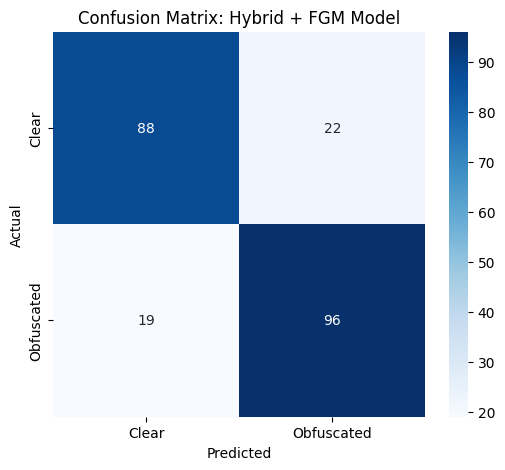

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions from your trainer
preds_output = trainer.predict(dataset_test)
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clear', 'Obfuscated'],
            yticklabels=['Clear', 'Obfuscated'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Hybrid + FGM Model')
plt.show()

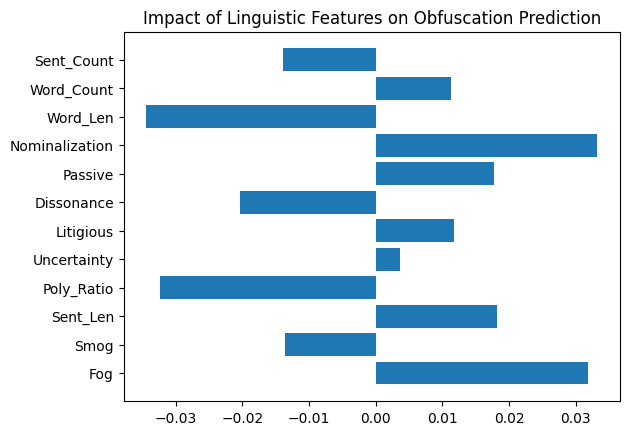

In [ ]:
import shap

# Simpler version: Visualize the weights of the Linear Classifier layer
weights = model.classifier.weight.detach().cpu().numpy()
# The last 12 weights correspond to your linguistic features
linguistic_weights = weights[1, -12:]

feature_names = ['Fog', 'Smog', 'Sent_Len', 'Poly_Ratio', 'Uncertainty',
                 'Litigious', 'Dissonance', 'Passive', 'Nominalization',
                 'Word_Len', 'Word_Count', 'Sent_Count']

plt.barh(feature_names, linguistic_weights)
plt.title('Impact of Linguistic Features on Obfuscation Prediction')
plt.show()

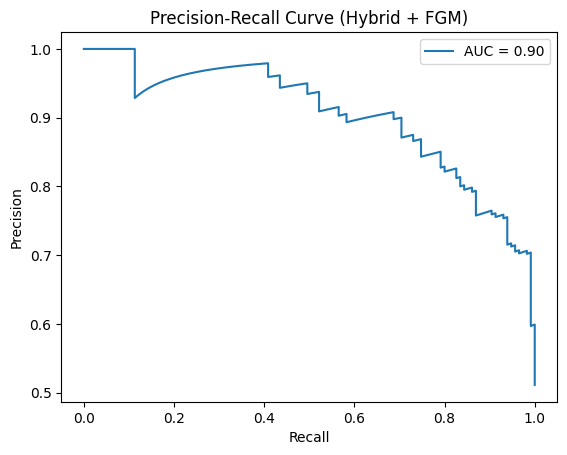

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# Get probabilities instead of hard classes
probs = torch.nn.functional.softmax(torch.tensor(preds_output.predictions), dim=1)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_true, probs)

plt.plot(recall, precision, label=f'AUC = {auc(recall, precision):.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Hybrid + FGM)')
plt.legend()
plt.show()

## **10. Baseline Model Comparisons**

To demonstrate the value of fine‑tuning and feature augmentation, we compare against two simple baselines.


### **10.1 VADER Sentiment**
Rule‑based sentiment analyzer. Here, a **negative compound score** is treated as obfuscated (1). Since obfuscation isn't simply negative sentiment, this serves as a naive baseline.

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import time

analyzer = SentimentIntensityAnalyzer()

def evaluate_vader_baseline(df):
    start_time = time.time()

    # 1. Run Predictions
    # Note: Obfuscation is often characterized by 'neutral' masks or 'negative' complexity.
    # We use the logic: Negative Sentiment (Score < 0) = Obfuscated (1)
    y_preds = df['text'].apply(lambda x: 1 if analyzer.polarity_scores(str(x))['compound'] < 0 else 0)
    y_true = df['binary_label']

    runtime = time.time() - start_time

    # 2. Calculate Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_preds, average='binary')
    acc = accuracy_score(y_true, y_preds)

    # 3. Format to match Hugging Face Trainer output
    vader_results = {
        'eval_loss': 0.0,  # VADER is rule-based, no loss calculation
        'eval_accuracy': acc,
        'eval_f1': f1,
        'eval_precision': precision,
        'eval_recall': recall,
        'eval_runtime': runtime,
        'eval_samples_per_second': len(df) / runtime if runtime > 0 else 0,
        'eval_steps_per_second': 0.0, # Not applicable for rule-based
        'epoch': 0.0 # Not applicable
    }

    return vader_results

# Execute and Print
print("VADER Baseline Evaluation:")
vader_results = evaluate_vader_baseline(df_test)
print(vader_results)

VADER Baseline Evaluation:
{'eval_loss': 0.0, 'eval_accuracy': 0.48, 'eval_f1': 0.0, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_runtime': 0.8824625015258789, 'eval_samples_per_second': 254.96834099006946, 'eval_steps_per_second': 0.0, 'epoch': 0.0}




### **10.2 Unfine‑tuned FinBERT**
Loads the pre‑trained FinBERT **without any fine‑tuning**. The classification head is randomly initialized. This measures how much domain adaptation improves performance.

Both baselines are evaluated using the same test set and metrics (accuracy, F1, precision, recall).

In [ ]:
import torch
from torch.utils.data import DataLoader

# Load the raw pretrained model (un-finetuned)
raw_model = BertForSequenceClassification.from_pretrained('yiyanghkust/finbert-pretrain', num_labels=2)
raw_model.eval()

def get_raw_finbert_preds(batch):
    inputs = tokenizer(batch['text'], padding=True, truncation=True, return_tensors="pt", max_length=512)
    with torch.no_grad():
        outputs = raw_model(**inputs)
        logits = outputs.logits
        return torch.argmax(logits, dim=-1).cpu().numpy()

# Apply to test set
raw_finbert_preds = []
for text in df_test['text']:
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt", max_length=512)
    with torch.no_grad():
        output = raw_model(**inputs)
        pred = torch.argmax(output.logits, dim=-1).item()
        raw_finbert_preds.append(pred)

print("Un-finetuned FinBERT Results:")
print(classification_report(df_test['binary_label'], raw_finbert_preds))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

Un-finetuned FinBERT Results:
              precision    recall  f1-score   support

           0       0.49      0.99      0.65       110
           1       0.00      0.00      0.00       115

    accuracy                           0.48       225
   macro avg       0.24      0.50      0.33       225
weighted avg       0.24      0.48      0.32       225



In [ ]:
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding

# 1. Load the raw model
raw_model = AutoModelForSequenceClassification.from_pretrained('yiyanghkust/finbert-pretrain', num_labels=2)
raw_model.to('cuda' if torch.cuda.is_available() else 'cpu')

# 2. FIX: Tokenization must include the 'labels' column
def tokenize_basic(ex):
    # Standard BERT tokenization
    tokenized = tokenizer(ex['text'], truncation=True, padding='max_length', max_length=128)

    # CRITICAL: Trainer looks for the key 'labels' to calculate metrics
    # Ensure your dataframe column 'binary_label' is mapped here
    tokenized['labels'] = ex['binary_label']
    return tokenized

# Re-map the dataset
ds_test_basic = Dataset.from_pandas(df_test).map(tokenize_basic, batched=True)

# 3. FIX: Ensure compute_metrics handles raw model output format
def compute_metrics_baseline(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    # Use 'binary' average since you are doing Obfuscation (0 or 1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 4. Initialize Trainer
raw_trainer = Trainer(
    model=raw_model,
    args=TrainingArguments(output_dir='temp_raw', per_device_eval_batch_size=8),
    train_dataset=None, # Not training
    eval_dataset=ds_test_basic,
    compute_metrics=compute_metrics_baseline # Use the fixed metric function
)

print("\n--- Unfine-tuned FinBERT Performance ---")
results = raw_trainer.evaluate()
print(results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

Map:   0%|          | 0/225 [00:00<?, ? examples/s]


--- Unfine-tuned FinBERT Performance ---


{'eval_loss': 0.706285834312439, 'eval_model_preparation_time': 0.0122, 'eval_accuracy': 0.5111111111111111, 'eval_f1': 0.6625766871165644, 'eval_precision': 0.5118483412322274, 'eval_recall': 0.9391304347826087, 'eval_runtime': 1.9114, 'eval_samples_per_second': 117.717, 'eval_steps_per_second': 15.172}


## **11. Comparative Performance Summary**

This bar chart visualizes **F1 scores** across all models tested:

1. Raw FinBERT (unfine‑tuned)
2. Vanilla Fine‑tuned FinBERT
3. + Simple Linguistic Features
4. + Advanced LM Dictionary Features
5. + Advanced Features + FGM

The progressive improvement from baseline to the final hybrid + FGM model demonstrates the value of:
- Domain‑specific fine‑tuning
- Linguistic feature augmentation
- Adversarial training for robustness

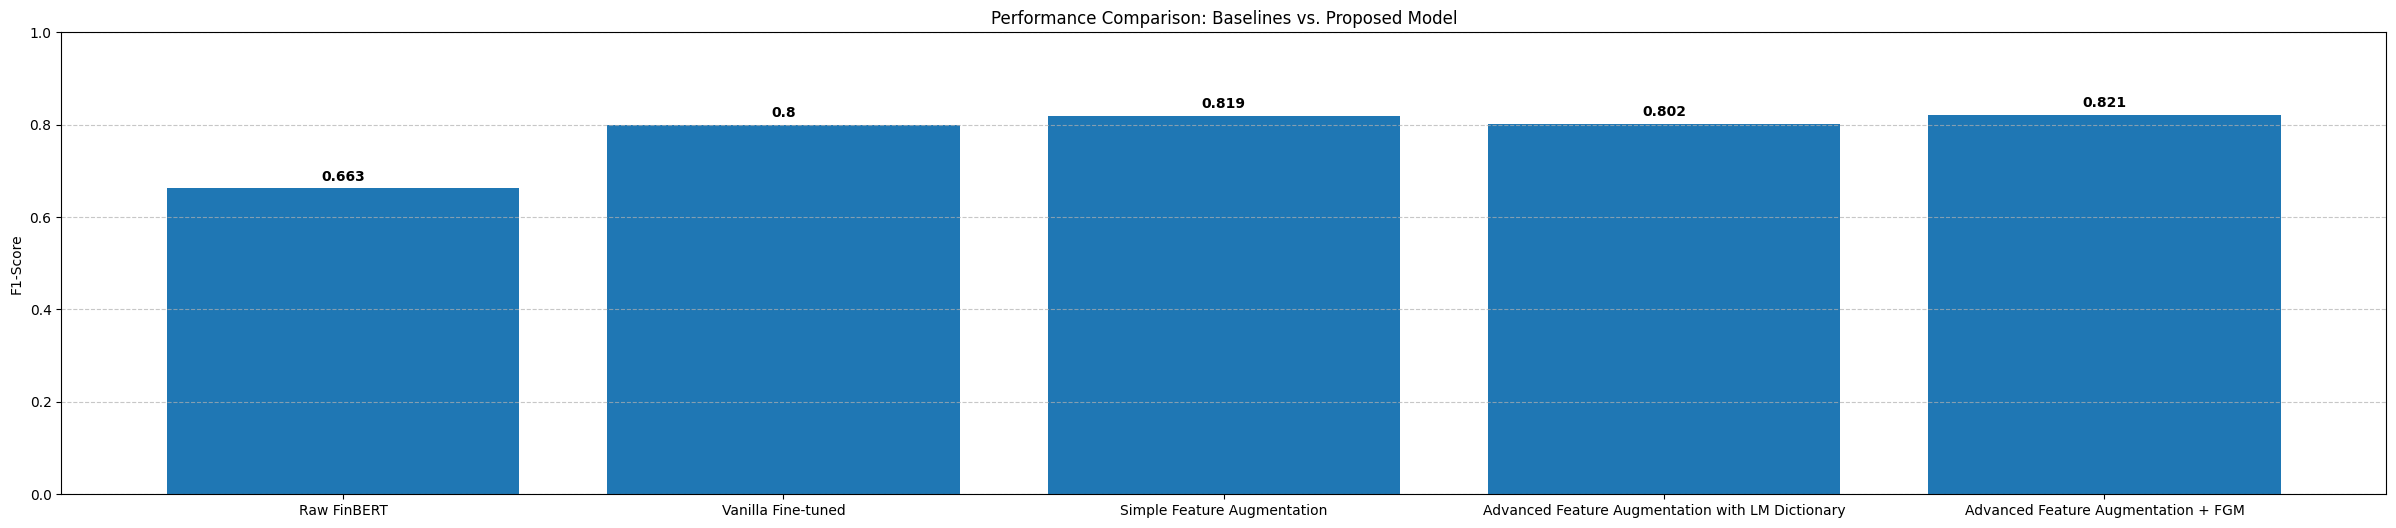

In [ ]:
import matplotlib.pyplot as plt

models = ['Raw FinBERT', 'Vanilla Fine-tuned', 'Simple Feature Augmentation','Advanced Feature Augmentation with LM Dictionary','Advanced Feature Augmentation + FGM']
# Replace these with your actual results
f1_scores = [0.6625766871165644, 0.80,0.8193832599118943, 0.8017241379310345, 0.8209606986899564]

plt.figure(figsize=(30, 6))
bars = plt.bar(models, f1_scores)

# Add the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3), ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 1.0)
plt.ylabel('F1-Score')
plt.title('Performance Comparison: Baselines vs. Proposed Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()